In [1]:
import ast
from time import time
import pickle
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split as tts


#from PySparseCoalescedTsetlinMachineCUDA.tm import MultiOutputTsetlinMachine
from cutm import MultiOutputTM

In [2]:
experiment_name = 'no_label_sampling_results_1_30000_2000_2500_5.0_2.0_100'

string_vars = experiment_name.split('_')
max_features = int(string_vars[-6])
n_clauses_per_class = int(string_vars[-5])
n_gram = int(string_vars[-7])

# Read the dataset file
filepath = '../../data/stortinget_dataset_clean.csv'
df = pd.read_csv(filepath)
df['emneord'] = df['emneord'].apply(ast.literal_eval)

# Create dictionary with 10 most common tags
all_emneord = np.sort(np.unique(df['emneord'].sum()))
emnedict = {str(k): v for v, k in zip(range(len(all_emneord)), all_emneord)}
tags, counts = np.unique(df['emneord'].sum(), return_counts=True)
common_tags_ind = np.argsort(-counts)[:10]

print("Most common labels\n", "-"*20)
emnedict_reduced = {}
for i, tag in enumerate(common_tags_ind):
    print(f"{tags[tag]} -- {counts[tag]}")
    emnedict_reduced[str(tags[tag])] = i
print(f"\nReduced emnedict: {emnedict_reduced}")

# Split datafram into train and test sets. Don't change the seed!
train, test = tts(df, test_size=0.2, random_state=1)
test_samples = test.index
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)


# Initialize the count-vectorizer and transform the data
with open("stop_words.txt", 'r') as infile:
    stop_words = [word.strip() for word in infile]

corpus = list(train.loc[:, 'sammendrag'].values)
vect = CountVectorizer(
    ngram_range=(1, n_gram),
    max_features=max_features,
    binary=True,
    stop_words=stop_words,
)

tic = time()
vect.fit(corpus)
toc = time()
print(f"Vectorizer trained in {toc - tic:.3f} seconds")

tic = time()
X_train = vect.transform(corpus).toarray()
toc = time()
print(f"Corpus transformed in {toc-tic:.3f} seconds")

tic = time()
X_test = vect.transform(list(test.loc[:, 'sammendrag'].values)).toarray()
toc = time()
print(f"Test data transformed in {toc-tic:.3f} seconds")


# Get the encoded labels from the dataframes
emneset = set(emnedict_reduced.keys())
def get_target_vect(df, emneset):
    Y = np.zeros([df.shape[0], len(emneset)], dtype=int)
    for i in range(df.shape[0]):
        labels = set(df.loc[i, 'emneord']).intersection(emneset)
        for l in labels:
            Y[i, emnedict_reduced[l]] = 1
    return Y

Y_train = get_target_vect(train.iloc[:], emneset)
Y_test = get_target_vect(test.iloc[:], emneset)

# Remove all samples without any labels
train = train[np.sum(Y_train, axis=1) > 0].reset_index(drop=True)
test = test[np.sum(Y_test, axis=1) > 0].reset_index(drop=True)
X_train = X_train[np.sum(Y_train, axis=1) > 0].astype(np.uint32)
Y_train = Y_train[np.sum(Y_train, axis=1) > 0].astype(np.uint32)
X_test = X_test[np.sum(Y_test, axis=1) > 0].astype(np.uint32)
Y_test = Y_test[np.sum(Y_test, axis=1) > 0].astype(np.uint32)

print(f"Number of training samples: {X_train.shape[0]}")
print(f"Number of test samples:     {X_test.shape[0]}")

# Create reversed emne-dictionary
reverse_emne = {v:k for k, v in emnedict_reduced.items()}

# Load the trained Tsetlin Machine model
FILENAME = f"{experiment_name}/model.pickle"
with open(FILENAME, 'rb') as infile:
    tm = pickle.load(infile)

# Print test set evaluation
Y_pred, CS = tm.predict(X_test)
print(classification_report(Y_test, Y_pred))

L = tm.get_literals()    # Matrix of TM literals
W = tm.get_weights()     # Matrix of TM weights

Most common labels
 --------------------
Eu/eøs -- 1090
Trygder -- 810
Helsevesen -- 791
Innvandrere -- 650
Forurensning -- 629
Internasjonalt samarbeid -- 535
Politi og påtalemyndighet -- 513
Departementer -- 502
Forskning -- 496
Kommunikasjonsteknologi -- 491

Reduced emnedict: {'Eu/eøs': 0, 'Trygder': 1, 'Helsevesen': 2, 'Innvandrere': 3, 'Forurensning': 4, 'Internasjonalt samarbeid': 5, 'Politi og påtalemyndighet': 6, 'Departementer': 7, 'Forskning': 8, 'Kommunikasjonsteknologi': 9}


/home/runarhe/virtualenvs/ytm/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aurdal', 'aurskog', 'eiker', 'elvdal', 'evje', 'fron', 'gauldal', 'hornnes', 'høland', 'land', 'midtre', 'mo', 'nord', 'nore', 'ordfører', 'ovre', 'publikasjonen', 'rana', 'slidre', 'stor', 'søndre', 'sør', 'toten', 'uvdal', 'varanger', 'vestre', 'østre', 'øvre', 'øystre'] not in stop_words.
  warnings.warn(


Vectorizer trained in 17.480 seconds
Corpus transformed in 17.674 seconds
Test data transformed in 5.056 seconds
Number of training samples: 3275
Number of test samples:     810


/home/runarhe/virtualenvs/ytm/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       0.89      0.93      0.91       213
           1       0.93      0.88      0.90       160
           2       0.87      0.90      0.88       155
           3       0.83      0.83      0.83       115
           4       0.76      0.93      0.84       131
           5       0.84      0.83      0.84       107
           6       0.91      0.91      0.91        91
           7       0.84      0.82      0.83        96
           8       0.75      0.79      0.77       108
           9       0.78      0.74      0.76        96

   micro avg       0.85      0.87      0.86      1272
   macro avg       0.84      0.86      0.85      1272
weighted avg       0.85      0.87      0.86      1272
 samples avg       0.86      0.90      0.87      1272



# Show important literals for specific samples

Predicted ['Innvandrere', 'Internasjonalt samarbeid', 'Forskning']
True      ['Innvandrere', 'Internasjonalt samarbeid', 'Forskning']
Class sums = [[-1169. -4282. -2504.   546. -3789.  2455. -4247. -1345.  3715. -4797.]]


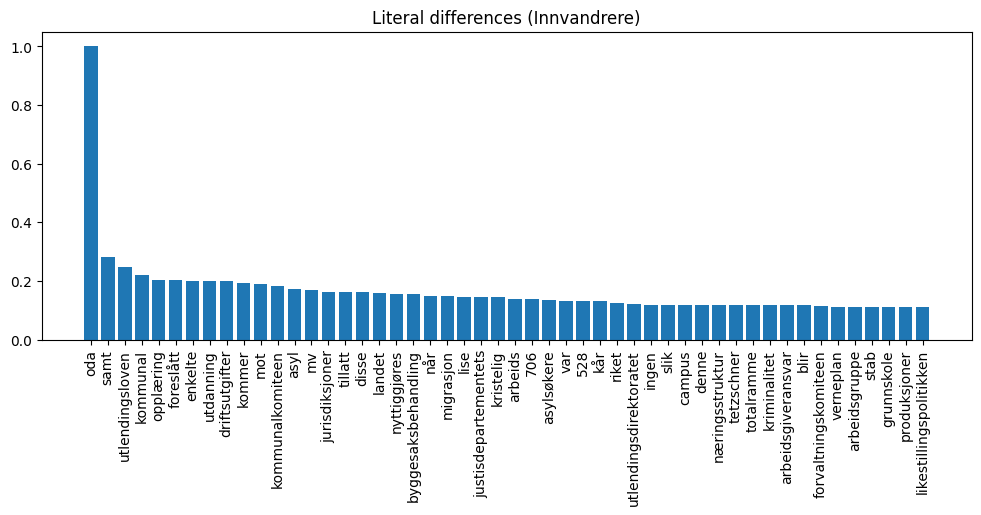

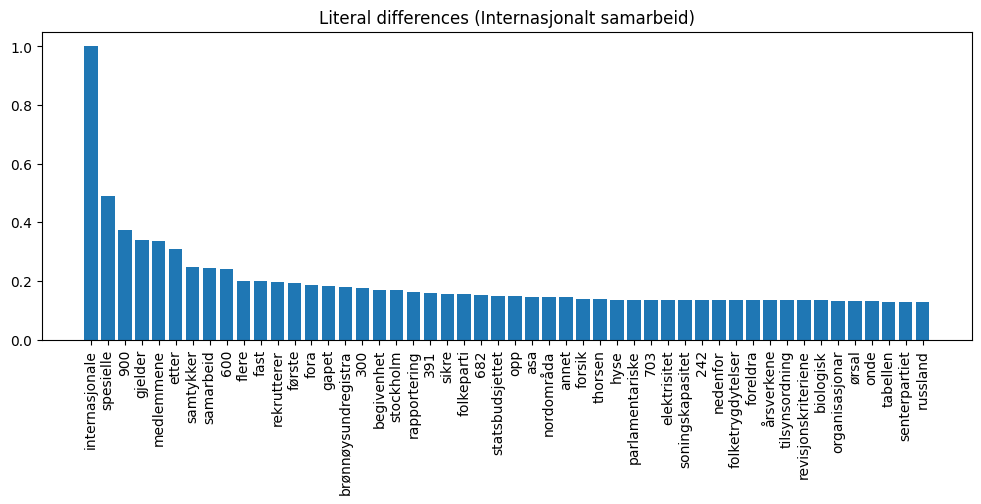

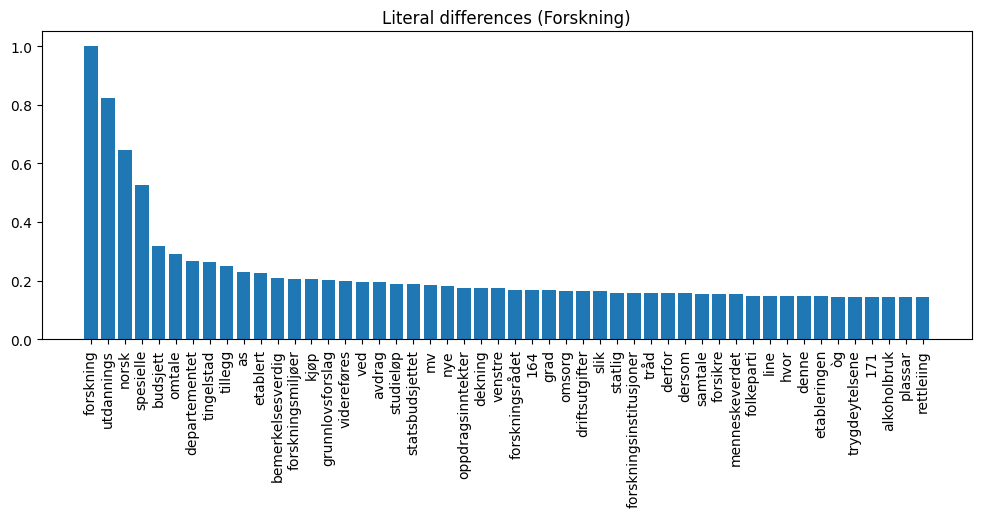

In [5]:
# Calculate the literal difference importance

words_limit=50    # How many literals to show in the figures
sample_id = 57     # The ID of the sample to show

n_features = L.shape[-1]//2

# Transform the sample document from text to active clauses via the tokenizer
x = vect.transform(list(test.loc[sample_id:sample_id, 'sammendrag'])).toarray().astype(np.uint32)
x_transformed = tm.transform(x.astype(np.uint32))[0].reshape(W.shape[0], n_clauses_per_class)

# Print the predictions and true labels
Y_pred, class_sum = tm.predict(x)
predicted_targets = np.nonzero(Y_pred[0])[0]
print("Predicted", [reverse_emne[x] for x in predicted_targets])
print("True     ", [reverse_emne[x] for x in np.nonzero(Y_test[sample_id])[0]])
print(f"Class sums = {class_sum}")


for target in predicted_targets:
    xt = x_transformed[target]
    S = (L[target, xt == 1, :] * W[target, xt == 1, target].reshape(-1, 1)).sum(axis=0)
    pos_lit = S[:n_features]
    neg_lit = S[n_features:]
    diff = (pos_lit - neg_lit)
    
    # Normalize negative and positive evidence separately
    diff[diff < 0] = -diff[diff < 0]/diff.min()
    diff[diff >= 0] = diff[diff >= 0]/diff.max()

    # Get the most importand words
    ind = np.argsort(-diff)
    words = vect.get_feature_names_out()[ind]

    # Create figure
    fig, ax = plt.subplots(figsize=[12, 4])
    ax.bar(words[:words_limit], diff[ind][:words_limit])
    ax.tick_params(axis='x', labelrotation=90)
    ax.set_title(f"Literal differences ({reverse_emne[target]})")

plt.show()

In [11]:
sample_id = 57



colors = ['\033[41m', '\033[42m', '\033[43m', '\033[44m', '\033[45m', '\033[46m', '\033[47m', '\033[40m', '\033[35m', '\033[34m']
def highlight_word(word, class_id):
    RESET = '\033[0m'
    return colors[class_id] + word + RESET

def highlight_with_ansi(text, words, class_id=0):
    HIGHLIGHT = colors[class_id]  # Yellow background
    RESET = '\033[0m'

    for word in words:
        #text = text.replace(word, f'{HIGHLIGHT}{word}{RESET}')
        pattern = r'\b' + re.escape(word) + r'\b'
        text = re.sub(pattern, f'{HIGHLIGHT}{word}{RESET}', text, flags=re.IGNORECASE)
    return text


x = vect.transform(list(test.loc[sample_id:sample_id, 'sammendrag'])).toarray().astype(np.uint32)
x_transformed = tm.transform(x.astype(np.uint32))[0].reshape(W.shape[0], n_clauses_per_class)

y_pred, cs = tm.predict(x)
y_pred = y_pred[0]
print(Y_test[sample_id])
print(y_pred)
print()

print(cs)

word_dict = vect.get_feature_names_out()

text = test.iloc[sample_id]['sammendrag']
tt = text
predicted_emner = np.argwhere(y_pred == 1).flatten()

for target in predicted_emner:
    print(f"EMNE={highlight_word(reverse_emne[target], class_id=target)}")

    n_feat = L.shape[-1] // 2
    A = L[target, xt == 1, :]   # Active literals
    WA = W[target, xt==1, target]
    positive = A[WA >= 0]    # positive polarity clauses
    
    pp = []
    for clause_id in range(positive.shape[0]):
        pos_lit = []
        neg_lit = []
        for i in range(A.shape[1]//2):
            pos_literal_value = positive[clause_id][i]
            if pos_literal_value == 1:
                pos_lit.append(word_dict[i])
            neg_literal_value = positive[clause_id][n_feat + i]
            if neg_literal_value == 1:
                neg_lit.append("¬" + word_dict[i])
        pp += pos_lit
        
    pp = list(set(pp))
    
    tt = highlight_with_ansi(tt, pp, class_id=target)

if len(predicted_emner > 0):
    print()
    print(tt)
else:
    print("Nothing predicted")
    print(tt)

[0 0 0 1 0 1 0 0 1 0]
[0 0 0 1 0 1 0 0 1 0]

[[-1169. -4282. -2504.   546. -3789.  2455. -4247. -1345.  3715. -4797.]]
EMNE=Innvandrere
EMNE=Internasjonalt samarbeid
EMNE=Forskning

Til stortinget 1.	Sammendrag 1.1	Innledning departementet foreslår i proposisjonen å endre enkelte bevilgninger i statsbudsjettet for 2004. Det gis også en omtale av disponeringen av bevilgningen til drift av opplæringsråd. videre fremmer departementet forslag om å gjøre utstyrsbevilgningen til statens lånekasse for utdanning overførbar, og om å stille en statlig garanti for forprosjektet for byggetrinn 2 for Kunsthøgskolen i Oslo på Seilduksfabrikken. 1.2	Forslag til endringer i statsbudsjettet for 2004 kap. 221 Grunnskolen (jf. kap. 3221) post 65 tilskudd til opplæring for språklige minoriteter i grunnskolen departementet foreslår å øke bevilgningen med om lag 43,9 mill. kroner. økningen skyldes at aktiviteten knyttet til opplæring av språklige minoriteter i grunnskolen, herunder opplæring av barn i asylm